In [1]:
import os
import sys
# Agrega la ruta raíz del proyecto si no está
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import openpyxl
from Funciones.Utils.utils_get_config_vars import *
from Funciones.Utils.utilidades import *
from Funciones.Carga.cargar_datos_csv import * 
from Funciones.Graficado.base.Gra_mapa_cartopy import graficar_mapa_cartopy
from Funciones.Graficado.base.Gra_mapa_topografia import graficar_mapa_topografico
from Funciones.Graficado.base.Gra_batimetria_en_mapa import graficar_batimetria_en_mapa        
from Funciones.Graficado.base.Gra_trayectorias_de_sonda import graficar_trayectorias_de_sonda
from Funciones.Graficado.base.Gra_dar_formato_a_figuras import *

In [3]:
datos_de_topografia = cargar_datos_de_topografia()
datos_de_topografia = recortar_datos_de_topografia_a_area_de_estudio(datos_de_topografia, -98, -90, 18, 26)
datos_de_topografia = reemplazar_valores_de_topografia(datos_de_topografia, valor_a_reemplazar=-10, nuevo_valor=-10)
datos_de_batimetria = cargar_datos_de_batimetria()

In [4]:
carpeta = "C:/Users/Atmosfera/Desktop/datos_crudos/doris_informes"
archivo = "2026_02_despliegues_de_DORIS.xlsx"
df = pd.read_excel(os.path.join(carpeta, archivo))

In [5]:
df.reset_index(inplace=True, drop=True)
df.dropna(subset=["serie_de_sonda"], inplace=True)
df["serie_de_sonda"] = df["serie_de_sonda"].astype(int).astype(str)

In [6]:
df.head()

,serie_de_sonda,serie_UABC,fecha_y_hora_de_despliegue,fecha_y_hora_de_la_primera_transmision,latitud_de_despliegue,longitud_de_despliegue,tirante_de_despligue,lugar_de_salida,encargado,Ruta a evidencias fotográficas,campania,fecha_y_hora_de_ultima_transmision,nombre_del_instrumento,seriales_instrumentos,fecha_y_hora_de_despliegue_corregida,latitud_corregida,longitud_corregida,notas_generales,eliminar_hasta_la_fila_inclusive,Unnamed: 19
0,4878221,B13,2025-12-01 05:02:00,NaN,NaN,NaN,-,CARMEN CAMPECHE,NaN,NaN,ASM-147-A,2025-12-01 00:00:00,NaN,NaN,2025-12-01 05:02:00,18.852143,-91.829053,Se desplegó y no transmitió información,0.0,NaN
7,4878218,B12,2025-12-01 06:11:00,2025-12-01 06:12:00,19.1672689 N,91.8443469 W,-,CARMEN CAMPECHE,NaN,NaN,ASM-147-A,2026-02-02 04:17:00,GPS primario,GPS-S1-01,2025-12-01 06:12:00,19.168514,-91.844823,NaN,0.0,NaN
14,4876187,B15,2025-12-01 07:15:00,2025-12-01 11:39:00,19.4137439 N,91.814135 W,-,CARMEN CAMPECHE,NaN,NaN,ASM-147-A,NaT,GPS primario,GPS-S3-01,2025-12-01 11:39:00,19.410943,-91.826327,NaN,0.0,NaN
21,4878205,B14,2025-12-01 08:34:00,2025-12-01 09:28:00,19.6374642 N,91.8676929 W,-,CARMEN CAMPECHE,NaN,NaN,ASM-147-A,2025-12-17 11:32:00,GPS primario,GPS-S2-01,2025-12-01 09:28:00,19.631442,-91.870444,NaN,0.0,NaN
28,4878196,B16,2025-12-01 11:10:00,2025-12-01 11:50:00,20.114217 N,91.880053 W,-,CARMEN CAMPECHE,NaN,NaN,ASM-147-A,NaT,GPS primario,GPS-S4-01,2025-12-01 11:50:00,20.108714,-91.879756,NaN,0.0,NaN


In [7]:
enero = [
    "4878221",
    "4866704",
    "4878503",
    "4876191",
    "4876190"
]

febrero_1 = [
    "4878319",
    "4878214",
    "4878152",
    "4876178",
    "4878225",
    "4878504"
]

febrero_2 = [
    "4878219",
    "4878190",
    "4878213",
    "4878203",
    "4876177"
]

In [8]:
dic = {}
dic["lat_enero"] = []
dic["lon_enero"] = []
dic["lat_febrero_1"] = []
dic["lon_febrero_1"] = []   
dic["lat_febrero_2"] = []
dic["lon_febrero_2"] = []

for serial in enero:
    df_serie = df[df["serie_de_sonda"] == serial]
    print(f"Serie: {serial}")
    latitud = float(df_serie["latitud_de_despliegue"].values[-1].split(" ")[0])
    longitud = float(df_serie["longitud_de_despliegue"].values[-1].split(" ")[0])
    dic["lat_enero"].append(latitud)
    dic["lon_enero"].append(-1*longitud)

for serial in febrero_1:
    df_serie = df[df["serie_de_sonda"] == serial]
    print(f"Serie: {serial}")
    latitud = float(df_serie["latitud_de_despliegue"].values[-1].split(" ")[0])
    longitud = float(df_serie["longitud_de_despliegue"].values[-1].split(" ")[0])
    dic["lat_febrero_1"].append(latitud)
    dic["lon_febrero_1"].append(-1*longitud)
    
for serial in febrero_2:
    df_serie = df[df["serie_de_sonda"] == serial]
    print(f"Serie: {serial}")
    latitud = float(df_serie["latitud_de_despliegue"].values[-1].split(" ")[0])
    longitud = float(df_serie["longitud_de_despliegue"].values[-1].split(" ")[0])
    dic["lat_febrero_2"].append(latitud)
    dic["lon_febrero_2"].append(-1*longitud)

Serie: 4878221
Serie: 4866704
Serie: 4878503
Serie: 4876191
Serie: 4876190
Serie: 4878319
Serie: 4878214
Serie: 4878152
Serie: 4876178
Serie: 4878225
Serie: 4878504
Serie: 4878219
Serie: 4878190
Serie: 4878213
Serie: 4878203
Serie: 4876177


In [9]:
dic

{'lat_enero': [18.881244, 18.870427, 18.874098, 18.539849, 18.553519],
 'lon_enero': [-92.746555, -92.745908, -92.765781, -93.29246, -93.307566],
 'lat_febrero_1': [19.359723,
  19.27085,
  19.33585,
  19.21216,
  19.24799,
  19.15826],
 'lon_febrero_1': [-92.162772,
  -92.33658,
  -92.46196,
  -92.4611,
  -92.57635,
  -92.56203],
 'lat_febrero_2': [20.561338, 20.657627, 20.725023, 20.888013, 20.905348],
 'lon_febrero_2': [-96.710873, -96.805892, -96.868563, -97.014473, -97.036292]}

Text(0.5, 1.0, 'Ubicación de los despliegues de DORIS en Enero y Febrero de 2026')

c:\programacion\codigos_python\drift_buoys\.venv\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
c:\programacion\codigos_python\drift_buoys\.venv\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
c:\programacion\codigos_python\drift_buoys\.venv\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
c:\programacion\codigos_python\drift_buoys\.venv\Lib\site-packages\cartopy\mpl\geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
c:\programacion\codigos_python\drift_buoys\.venv\Lib\site-packages\cartopy\m

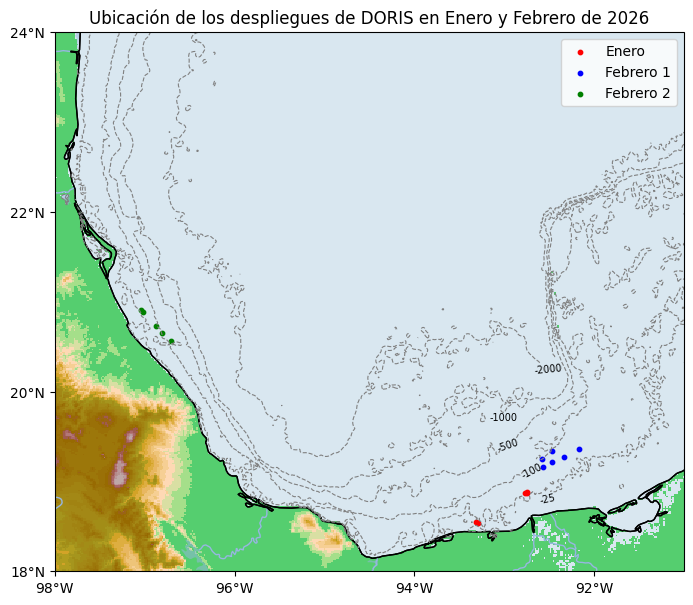

In [11]:
fig, ax = plt.subplots(figsize=(16, 7), subplot_kw={'projection': ccrs.PlateCarree()})
graficar_mapa_cartopy(ax, -98, -91, 18, 24)
graficar_mapa_topografico(axe=ax, topografia=datos_de_topografia, lon_min=-98, lon_max=-91, lat_min=18, lat_max=24)
graficar_batimetria_en_mapa(ax, datos_de_batimetria = datos_de_batimetria)
ax.scatter(dic["lon_enero"], dic["lat_enero"], c = "red", s=10, label="Enero")
ax.scatter(dic["lon_febrero_1"], dic["lat_febrero_1"], c = "blue", s=10, label="Febrero 1")
ax.scatter(dic["lon_febrero_2"], dic["lat_febrero_2"], c = "green", s=10, label="Febrero 2")
ax.legend()
ax.set_title("Ubicación de los despliegues de DORIS en Enero y Febrero de 2026")